<a href="https://colab.research.google.com/github/baynobu/PCVK-Ganjil-26/blob/main/P6_01_Abdul_Rahman_Hanif_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul 6 – Filter Spasial
**Mata Kuliah:** Pengolahan Citra dan Visi Komputer  
**Jurusan:** Teknologi Informasi - Politeknik Negeri Malang  

---
### Identitas Mahasiswa
* **Nama :** Abdul Rahman Hanif D
* **NIM  :** 2341720000 *(Silakan sesuaikan NIM jika diperlukan)*
* **Kelas / No. Absen :** 01
---

## D. PRAKTIKUM FILTER
Pada bagian ini akan dilakukan pembuatan fungsi konvolusi 2D secara mandiri (tanpa menggunakan library konvolusi OpenCV seperti `cv2.filter2D`) sesuai algoritma pada Bagian C Ulasan Teori.

In [1]:
# Cell Identitas Mahasiswa
NAMA = 'Abdul Rahman Hanif D'
NIM  = '244107020232'          # ganti dengan NIM sendiri jika diperlukan
print(f"Nama : {NAMA}")
print(f"NIM  : {NIM}")

Nama : Abdul Rahman Hanif D
NIM  : 244107020232


### Langkah Praktikum:
1. Mengakses file pada Google Drive dan mengimpor pustaka (library) yang diperlukan.
2. Alamat direktori citra disetel sesuai konfigurasi: `/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/`.

In [2]:
# Akses Google Drive dan Import Library
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from PIL import Image as im

# Coba import modul Google Colab jika dijalankan di Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    from google.colab.patches import cv2_imshow
    IN_COLAB = True
    print("Google Drive berhasil di-mount.")
except ImportError:
    IN_COLAB = False
    print("Menjalankan pada environment lokal (Non-Colab).")

# Direktori penyimpanan citra pada Google Drive
BASE_IMAGE_DIR = '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/'

def get_image_path(filename):
    """Helper untuk mendapatkan path absolut citra baik di Colab (Drive) maupun lokal."""
    drive_path = os.path.join(BASE_IMAGE_DIR, filename)
    if os.path.exists(drive_path):
        return drive_path
    elif os.path.exists(filename):
        return filename
    return drive_path  # Default ke path Google Drive

Mounted at /content/drive
Google Drive berhasil di-mount.


### 1. Membuat Fungsi Konvolusi 2D Mandiri (Tanpa Library OpenCV)
Sesuai instruksi Bagian C dan D:
* Parameter yang digunakan:
  1. `image` : Matriks citra masukan 2D (grayscale)
  2. `kernel` : Matriks kernel/filter 2D
  3. `stride` : Besaran langkah pergeseran jendela konvolusi (default: 1)
  4. `padding`: Besaran penambahan piksel batas nol di sekeliling citra (zero-padding, default: 2)
  5. `title`  : Judul visualisasi citra (opsional)

In [3]:
# Membuat fungsi konvolusi tanpa library konvolusi OpenCV
def convolution2d(image, kernel, stride=1, padding=2, title=""):
    """
    Fungsi konvolusi 2D manual menggunakan algoritma spasial.
    """
    # Ambil ukuran kernel
    k_h, k_w = kernel.shape

    # 1. Melakukan zero-padding pada citra masukan
    if padding > 0:
        padded_image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    else:
        padded_image = image.copy()

    pad_h, pad_w = padded_image.shape

    # 2. Menghitung dimensi matriks keluaran berdasarkan rumus konvolusi spasial
    out_h = int((pad_h - k_h) / stride) + 1
    out_w = int((pad_w - k_w) / stride) + 1

    # Inisialisasi matriks hasil konvolusi dengan float32 untuk menghindari overflow
    output = np.zeros((out_h, out_w), dtype=np.float32)

    # 3. Proses konvolusi (geser kernel, kalikan elemen, lalu jumlahkan)
    for i in range(out_h):
        for j in range(out_w):
            # Ekstraksi sub-wilayah (window) citra seukuran kernel
            region = padded_image[i * stride : i * stride + k_h, j * stride : j * stride + k_w]
            # Penjumlahan hasil perkalian dot antara sub-wilayah dan kernel
            output[i, j] = np.sum(region * kernel)

    # 4. Clipping nilai piksel agar berada di rentang valid [0, 255]
    output_clipped = np.clip(output, 0, 255).astype(np.uint8)

    # 5. Visualisasi hasil konvolusi seperti pada tampilan modul
    plt.figure(figsize=(6, 6))
    plt.imshow(output_clipped, cmap='gray')
    if title:
        plt.title(title)
    plt.show()

    return output_clipped

### 2. Load Citra Masukan dan Konversi ke Grayscale
Memuat citra `mandrill.tiff` dari direktori Drive `/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/mandrill.tiff`.

In [4]:
# Load Image yang akan diproses
mandrill_path = get_image_path('mandrill.tiff')
img = cv.imread(mandrill_path)

if img is None:
    raise FileNotFoundError(f"Citra tidak ditemukan di {mandrill_path}. Pastikan drive sudah ter-mount dan file sudah berada pada folder tersebut.")

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
print(f"Berhasil memuat citra: {mandrill_path}")
print(f"Dimensi citra grayscale: {img_gray.shape}")

Berhasil memuat citra: /content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/mandrill.tiff
Dimensi citra grayscale: (512, 512)


### 3. Menentukan Kernel Sharpen dan Menjalankan Konvolusi
Menguji pemanggilan fungsi `convolution2d(img_gray, kernel_sharpen, 1, 2)`.

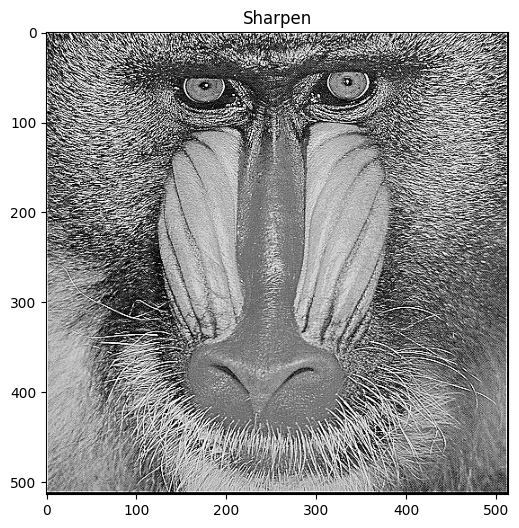

In [5]:
# Menentukan kernel yang akan digunakan
# image sharpen
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], dtype=np.float32)

# Memanggil fungsi konvolusi dan menerapkan filter sharpening
res_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2, title="Sharpen")

### 4. Implementasi Berbagai Filter Spasial (Bagian D No. 3)
Sesuai ketentuan Bagian D No. 3 modul, dibuat filter spasial untuk:
1. **Sharpen Filter**
2. **Emboss Filter**
3. **Left Sobel Edge Detection**
4. **Canny Edge Detection** (menggunakan kernel Laplacian 8-arah sesuai tabel modul)
5. **21x21 Gaussian Blur** (dengan pembangkitan kernel otomatis `cv.getGaussianKernel`)
6. **Average Filter 3x3** (dari Bagian C Page 11)
7. **Low Pass Filter 3x3** (dari Bagian C Page 11)
8. **High Pass Filter 3x3** (dari Bagian C Page 11)

=== 1. Sharpen Filter ===


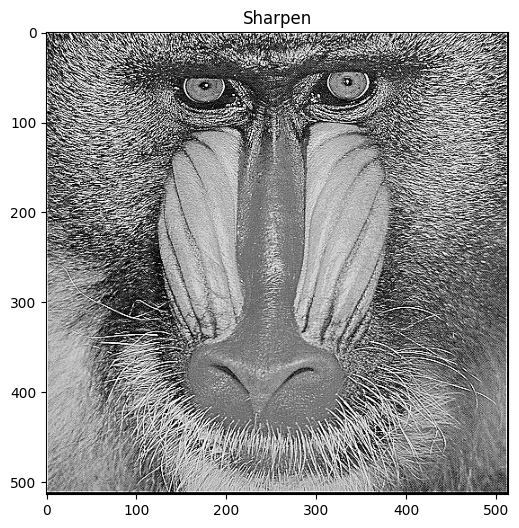

In [6]:
# 1. Sharpen Filter
print("=== 1. Sharpen Filter ===")
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], dtype=np.float32)
res_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2, title="Sharpen")

=== 2. Emboss Filter ===


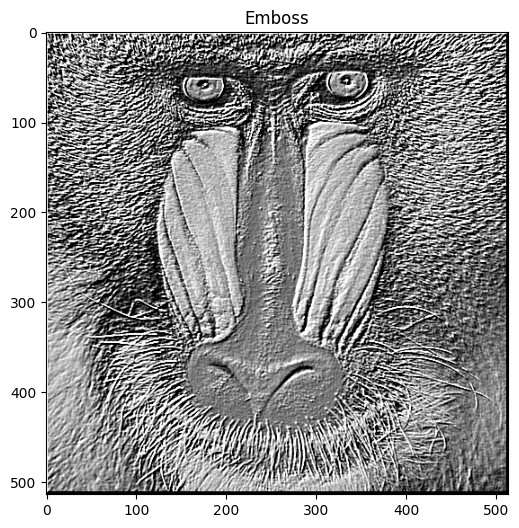

In [7]:
# 2. Emboss Filter
print("=== 2. Emboss Filter ===")
kernel_emboss = np.array([[-2, -1,  0],
                          [-1,  1,  1],
                          [ 0,  1,  2]], dtype=np.float32)
res_emboss = convolution2d(img_gray, kernel_emboss, 1, 2, title="Emboss")

=== 3. Left Sobel Edge Detection ===


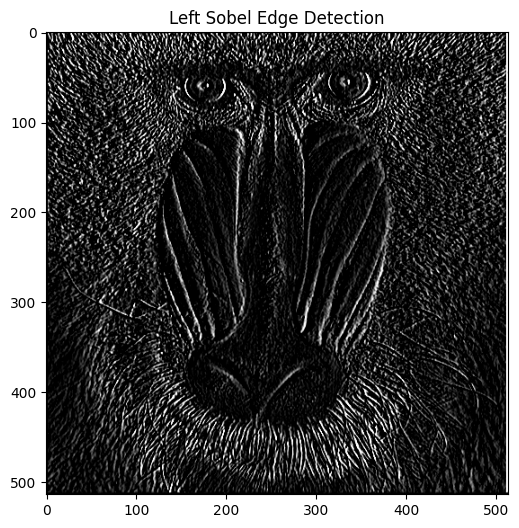

In [8]:
# 3. Left Sobel Edge Detection
print("=== 3. Left Sobel Edge Detection ===")
kernel_left_sobel = np.array([[ 1,  0, -1],
                             [ 2,  0, -2],
                             [ 1,  0, -1]], dtype=np.float32)
res_left_sobel = convolution2d(img_gray, kernel_left_sobel, 1, 2, title="Left Sobel Edge Detection")

=== 4. Canny Edge Detection ===


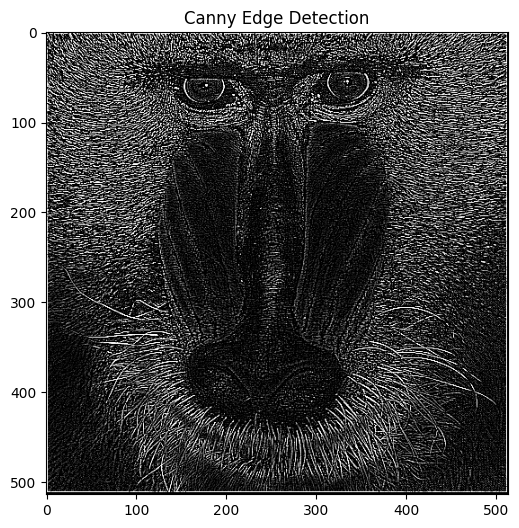

In [9]:
# 4. Canny Edge Detection (Kernel Laplacian 8-arah sesuai tabel Modul Hal. 16)
print("=== 4. Canny Edge Detection ===")
kernel_canny_laplacian = np.array([[-1, -1, -1],
                                   [-1,  8, -1],
                                   [-1, -1, -1]], dtype=np.float32)
res_canny = convolution2d(img_gray, kernel_canny_laplacian, 1, 2, title="Canny Edge Detection")

=== 5. 21x21 Gaussian Blur ===


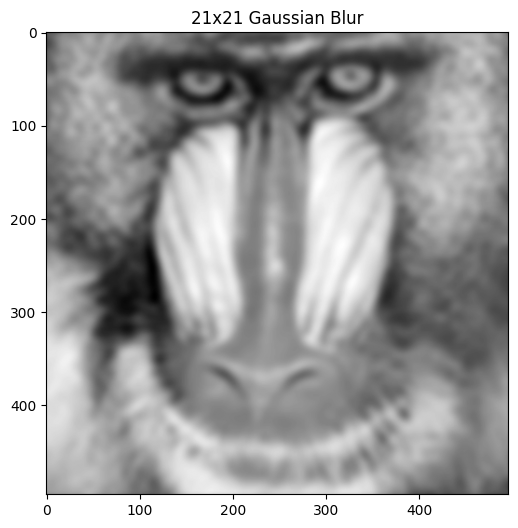

In [10]:
# 5. 21x21 Gaussian Blur
print("=== 5. 21x21 Gaussian Blur ===")
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

res_gauss_blur = convolution2d(img_gray, gauss_kernel, 1, 2, title="21x21 Gaussian Blur")

=== 6. Average Filter 3x3 ===


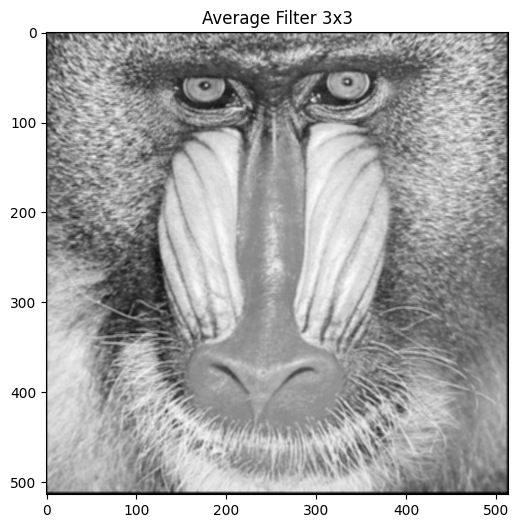

In [11]:
# 6. Average Filter 3x3 (Sesuai Modul Halaman 11)
print("=== 6. Average Filter 3x3 ===")
kernel_average = (1.0 / 9.0) * np.array([[1, 1, 1],
                                         [1, 1, 1],
                                         [1, 1, 1]], dtype=np.float32)
res_avg = convolution2d(img_gray, kernel_average, 1, 2, title="Average Filter 3x3")

=== 7. Low Pass Filter 3x3 ===


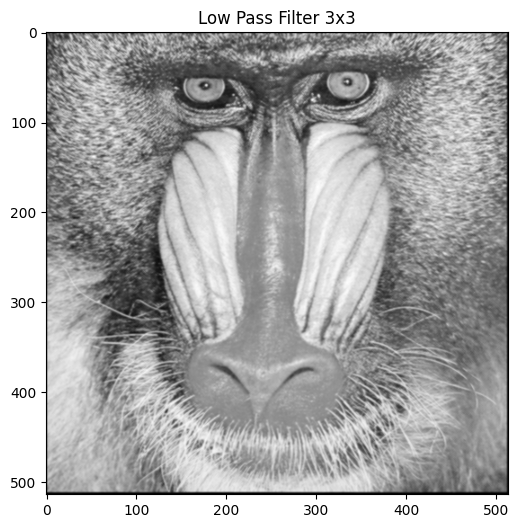

In [12]:
# 7. Low Pass Filter 3x3 (Sesuai Modul Halaman 11)
print("=== 7. Low Pass Filter 3x3 ===")
kernel_low_pass = (1.0 / 12.0) * np.array([[1, 1, 1],
                                           [1, 4, 1],
                                           [1, 1, 1]], dtype=np.float32)
res_low_pass = convolution2d(img_gray, kernel_low_pass, 1, 2, title="Low Pass Filter 3x3")

=== 8. High Pass Filter 3x3 ===


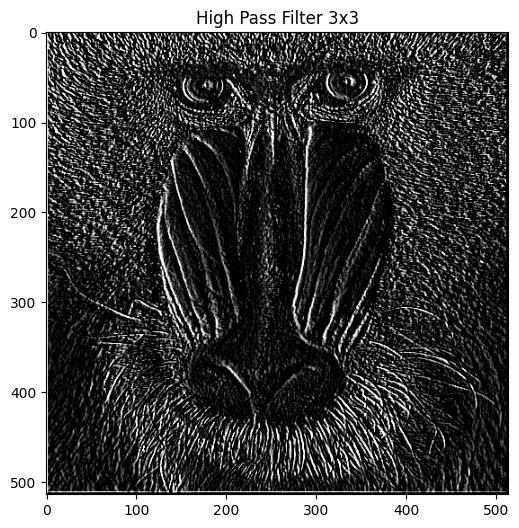

In [13]:
# 8. High Pass Filter 3x3 (Sesuai Modul Halaman 11)
print("=== 8. High Pass Filter 3x3 ===")
kernel_high_pass = np.array([[-1, 0, 1],
                             [-1, 0, 3],
                             [-3, 0, 1]], dtype=np.float32)
res_high_pass = convolution2d(img_gray, kernel_high_pass, 1, 2, title="High Pass Filter 3x3")

## E. FILTER LIBRARY DAN FILTER MODERN
Pada bagian ini akan dipelajari berbagai teknik filtering menggunakan pustaka bawaan OpenCV, filter modern yang digunakan pada Deep Learning / CNN, serta kombinasi filter modern untuk efek visual populer.

In [14]:
# Fungsi pembantu untuk menampilkan citra berdampingan (show_side_by_side)
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img_item, title) in enumerate(zip(images, titles)):
        if len(img_item.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img_item, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img_item, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

### Percobaan 1: Filter Gaussian, Sharpen, dan Canny pada Citra RGB menggunakan Library OpenCV
Pada percobaan ini filter diterapkan langsung pada citra RGB `lena.jpg` menggunakan `cv.GaussianBlur`, `cv.filter2D`, dan `cv.Canny`.

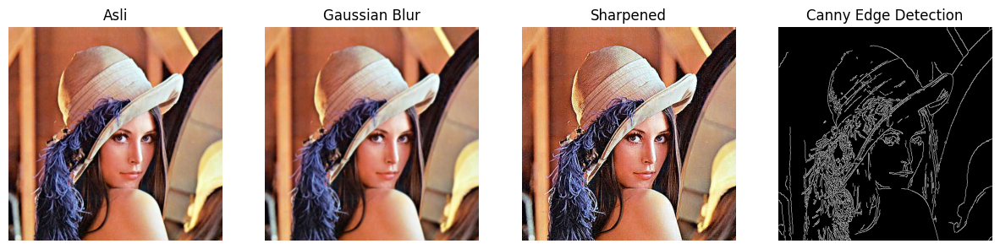

In [15]:
# Percobaan 1: Filter Gaussian, Sharpen, dan Canny menggunakan library OpenCV
lena_path = get_image_path('lena.jpg')
img_lena = cv.imread(lena_path)

if img_lena is None:
    raise FileNotFoundError(f"Citra lena.jpg tidak ditemukan pada {lena_path}")

img_gray_lena = cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img_lena, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])
sharpened = cv.filter2D(img_lena, -1, sharpen_kernel)

show_side_by_side([img_lena, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

### Percobaan 2: Filter Modern OpenCV (Bilateral Filter dan Edge Preserving Filter)
* **Bilateral Filter:** Menghaluskan permukaan warna namun tetap mempertahankan garis tepi secara non-linear (mempertimbangkan kedekatan spasial sekaligus perbedaan warna).
* **Edge Preserving Filter:** Alternatif guided filter yang sangat efisien untuk menghaluskan tekstur tanpa mengaburkan detail kontur wajah.

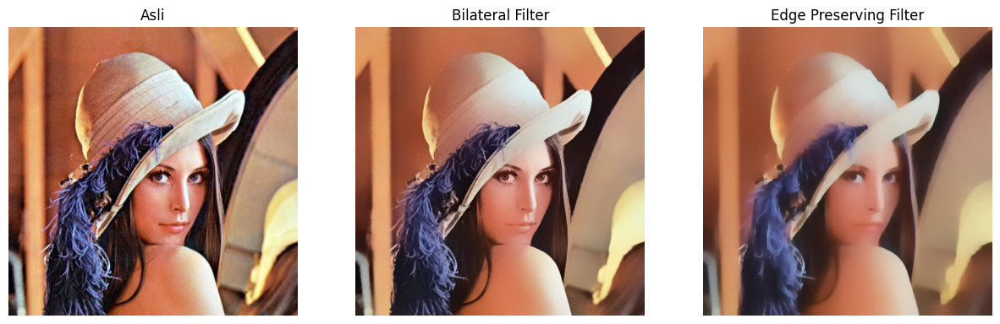

In [16]:
# Percobaan 2: Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img_lena, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img_lena, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img_lena, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

### Percobaan 3: Filtering pada Convolutional Neural Network (CNN) - Bagian Feature Map
Memvisualisasikan proses filtering 2D konvolusi yang bekerja di dalam layer CNN menggunakan pustaka PyTorch (`torch.nn.Conv2d`).

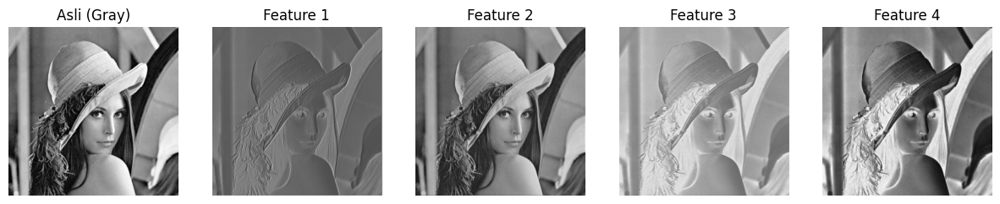

In [17]:
# Percobaan 3: Filter Feature Map yang digunakan pada CNN
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 1 kanal input (grayscale), 4 kanal output (4 feature maps), kernel 3x3, stride 1, padding 1
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

# Inisialisasi model CNN
model = SimpleCNN()

# Ubah gambar ke tensor (B, C, H, W) dan normalisasi ke rentang [0, 1]
img_tensor = torch.tensor(img_gray_lena, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Forward pass untuk mendapatkan feature maps
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray_lena] + feature_maps,
                  ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

#### Analisis dan Kesimpulan Percobaan 3:
> **Pertanyaan Modul:** *Lakukan running code beberapa kali dan perhatikan hasil outputnya. Apa yang dapat kamu simpulkan dari hasil keluaran tersebut?*

**Kesimpulan:**
1. **Inisialisasi Bobot Acak (Random Weight Initialization):** Setiap kali model CNN baru diinisialisasi tanpa menyetel *random seed*, nilai bobot kernel pada layer konvolusi `nn.Conv2d` diacak secara random (biasanya menggunakan distribusi Kaiming Uniform atau Xavier).
2. **Variasi Fitur Setiap Eksekusi:** Setiap kali kode dijalankan ulang dengan model baru, ke-4 *feature maps* yang dihasilkan akan menampilkan hasil ekstraksi yang berbeda-beda. Suatu filter mungkin merespons tepi vertikal, filter lain menonjolkan tekstur rambut, filter lain membalik intensitas (inversi/negatif), atau menonjolkan area kontras tinggi tertentu.
3. **Perbedaan dengan Filter Tradisional:**
   * Pada **filter tradisional** (seperti Sobel, Prewitt, Sharpening), nilai matriks kernel dirancang dan ditentukan secara manual (*handcrafted*) oleh manusia dengan tujuan matematis yang kaku.
   * Pada **CNN (Deep Learning)**, nilai matriks kernel dipelajari secara otomatis (*learned filters*) selama proses *training* melalui optimasi *gradient descent* dan *backpropagation*, sehingga jaringan mampu menemukan representasi fitur visual yang paling optimal untuk tugas tertentu (seperti klasifikasi, deteksi objek, atau segmentasi).

### Percobaan 4: Efek Beauty Filter dan Old/Vintage Filter
Menggabungkan beberapa teknik filter dasar untuk menciptakan filter estetika yang biasa ditemukan di aplikasi kamera modern.

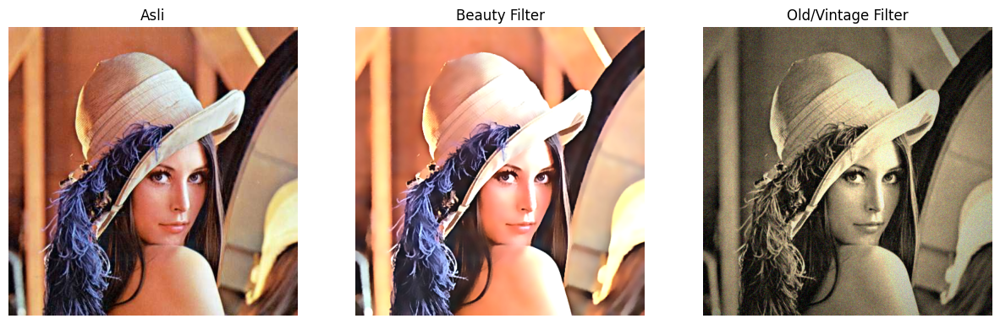

In [18]:
# Percobaan 4: Efek Beauty dan Old/Vintage Filter

# ============================
# 1. Beauty Filter
# ============================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img_lena, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (mempertajam area mata, bibir, kontur)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Peningkatan brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# ============================
# 2. Old/Vintage Filter
# ============================
# Step 1: Sepia tone transform
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img_lena, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette (pemberian bayangan menggelap di sudut citra)
rows, cols = img_lena.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise/Grain (memberi tekstur butiran film klasik)
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Menampilkan hasil berdampingan
show_side_by_side([img_lena, beauty, old_img],
                  ["Asli", "Beauty Filter", "Old/Vintage Filter"])

### Percobaan 5: Anime / Cartoon Filter
Menghasilkan efek kartun 2 dimensi dengan mendeteksi garis kontur tebal menggunakan *Adaptive Thresholding* dan meratakan gradasi warna menggunakan *Bilateral Filter*.

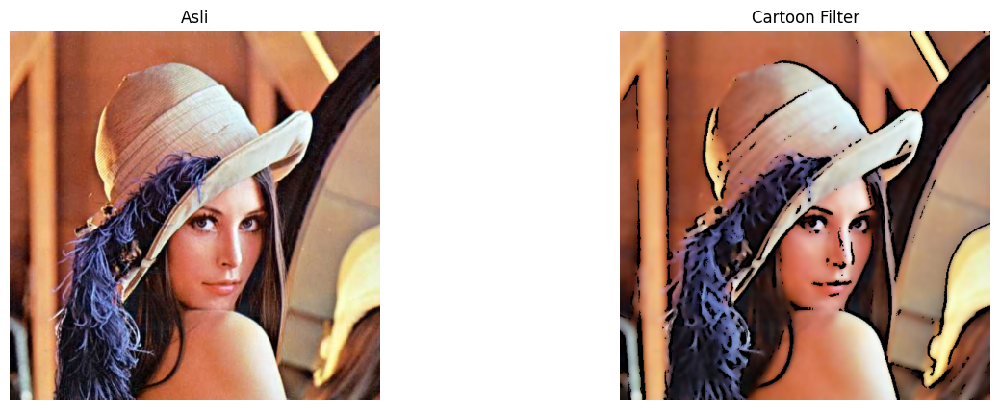

In [19]:
# Percobaan 5: Filter Anime / Cartoon
# Step 1: Edge detection (menggunakan median blur terlebih dahulu agar garis tidak pecah/berisik)
gray = cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna (cel-shaded look)
color = cv.bilateralFilter(img_lena, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize) dengan operasi bitwise AND
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan hasil
show_side_by_side([img_lena, cartoon], ["Asli", "Cartoon Filter"])

### Percobaan 6: Night Filter
Mengubah suasana siang/terang menjadi suasana malam hari dengan penurunan kecerahan, penambahan *blue tint*, dan efek *glow* pada citra pemandangan `djawatan.jpg`.

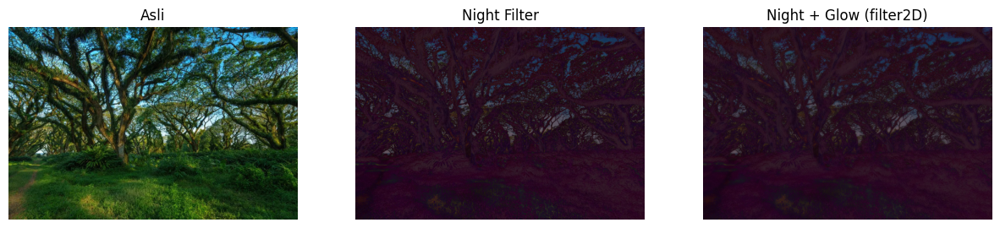

In [20]:
# Percobaan 6: Night Filter
djawatan_path = get_image_path('djawatan.jpg')
img_djawatan = cv.imread(djawatan_path)

if img_djawatan is None:
    raise FileNotFoundError(f"Citra djawatan.jpg tidak ditemukan di {djawatan_path}")

img_gray_djawatan = cv.cvtColor(img_djawatan, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan citra (kontras turun, brightness negatif)
night = cv.convertScaleAbs(img_djawatan, alpha=0.6, beta=-40)

# Step 2: Tambah bias warna biru malam (blue tint)
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel rata-rata 15x15)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Step 4: Kombinasikan citra malam dengan glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img_djawatan, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

### Percobaan 7: Suasana Pagi dan Kabut
Menciptakan suasana pagi berkabut pada citra `djawatan.jpg` dengan menambahkan *warm tint* (oranye/keemasan) dan lapisan kabut (*haze*) berbasis kernel Gaussian.

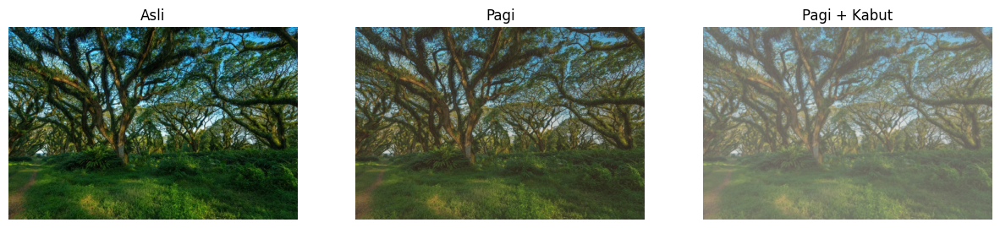

In [21]:
# Percobaan 7: Filter Suasana Pagi dan Kabut
# ============================
# Step 1: Kurangi kontras & cerahkan sedikit
# ============================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img_djawatan, alpha=alpha, beta=beta)

# ============================
# Step 2: Tambahkan warm tone (kemerahan / oranye keemasan fajar)
# ============================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ============================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ============================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # konversi ke kernel 2D
kabut = cv.filter2D(pagi, -1, kernel)

# Tambah layer putih untuk efek kabut lebih realistis
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img_djawatan, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

## TUGAS PRAKTIKUM

---
### Tugas 1: Analisis Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and Pepper”
1. Tambahkan noise bintik hitam-putih (*Salt and Pepper*) ke sebuah citra keabuan (*grayscale*).
2. Terapkan **Mean Filter (3 x 3)** dan **Median Filter (3 x 3)**.
3. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus noise tersebut dibanding Mean Filter.

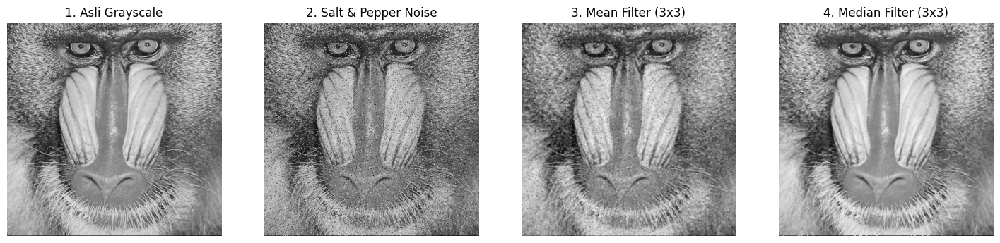

In [22]:
# Tugas 1: Implementasi Salt and Pepper Noise, Mean Filter, dan Median Filter

def add_salt_and_pepper_noise(image, salt_prob=0.03, pepper_prob=0.03):
    """Menambahkan noise bintik garam (putih) dan lada (hitam) pada citra keabuan."""
    noisy_image = image.copy()
    total_pixels = image.size

    # Tambahkan Salt noise (piksel bernilai 255 / putih)
    num_salt = int(np.ceil(salt_prob * total_pixels))
    coords_salt = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy_image[tuple(coords_salt)] = 255

    # Tambahkan Pepper noise (piksel bernilai 0 / hitam)
    num_pepper = int(np.ceil(pepper_prob * total_pixels))
    coords_pepper = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy_image[tuple(coords_pepper)] = 0

    return noisy_image

# 1. Menambahkan noise salt and pepper pada citra grayscale mandrill
noisy_mandrill = add_salt_and_pepper_noise(img_gray, salt_prob=0.04, pepper_prob=0.04)

# 2. Menerapkan Mean Filter 3x3
mean_filtered = cv.blur(noisy_mandrill, (3, 3))

# 3. Menerapkan Median Filter 3x3
median_filtered = cv.medianBlur(noisy_mandrill, 3)

# 4. Menampilkan perbandingan visual berdampingan
show_side_by_side([img_gray, noisy_mandrill, mean_filtered, median_filtered],
                  ["1. Asli Grayscale", "2. Salt & Pepper Noise", "3. Mean Filter (3x3)", "4. Median Filter (3x3)"],
                  figsize=(18, 5))

#### Analisis Tugas 1:
**Mengapa Median Filter jauh lebih bersih dalam menghapus noise Salt and Pepper dibanding Mean Filter?**

1. **Karakteristik Noise Salt and Pepper:**
   * Noise impuls ini berupa nilai ekstrem pada kedua ujung skala intensitas: nilai **0 (hitam pekat/pepper)** dan nilai **255 (putih murni/salt)** yang muncul secara acak pada piksel individual tanpa korelasi dengan intensitas sekitarnya.

2. **Kelemahan Mean Filter (Linear Spatial Filter):**
   * Mean filter bekerja dengan menjumlahkan seluruh nilai piksel dalam jendela $3 \times 3$ lalu membaginya dengan jumlah total piksel (9).
   * Nilai ekstrem 0 atau 255 ikut dijumlahkan ke dalam perhitungan rata-rata. Akibatnya, nilai ekstrem tersebut merusak rata-rata aritmatika dan menyebar (*blur/smudge*) ke piksel-piksel normal di sekitarnya.
   * Dampak visual: Bintik hitam-putih tidak hilang, melainkan berubah menjadi noda abu-abu buram yang mengotori citra, sementara tepi dan detail ketajaman citra aslinya ikut kabur (*blurry*).

3. **Keunggulan Median Filter (Non-Linear Order-Statistic Filter):**
   * Median filter mengurutkan seluruh 9 piksel tetangga dari nilai terkecil hingga terbesar, lalu mengambil nilai yang berada persis di posisi tengah (median/indeks ke-5).
   * Karena nilai noise salt (255) berada di posisi paling kanan (tertinggi) dan noise pepper (0) berada di posisi paling kiri (terendah), kedua nilai pencilan (*outliers*) tersebut **hampir mustahil terpilih sebagai nilai tengah**.
   * Dampak visual: Bintik salt and pepper berhasil dieliminasi secara total (100% bersih) dan digantikan oleh nilai piksel asli lingkungan sekitarnya, tanpa mengaburkan ketajaman kontur tepi (*edge-preserving*).

---
### Tugas 2: Evaluasi Pemilihan Ukuran Kernel Terbaik untuk Menajamkan Citra (Sharpening)
1. Buat kernel penajaman (*Sharpening Kernel*) ukuran **3 x 3** dan **5 x 5**.
2. Terapkan pada citra yang sedikit buram (*blurry*).
3. Evaluasi hasilnya berdasarkan aspek **Kejelasan Tepi** vs. **Kadar Noise / Noise Distortion** yang dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.

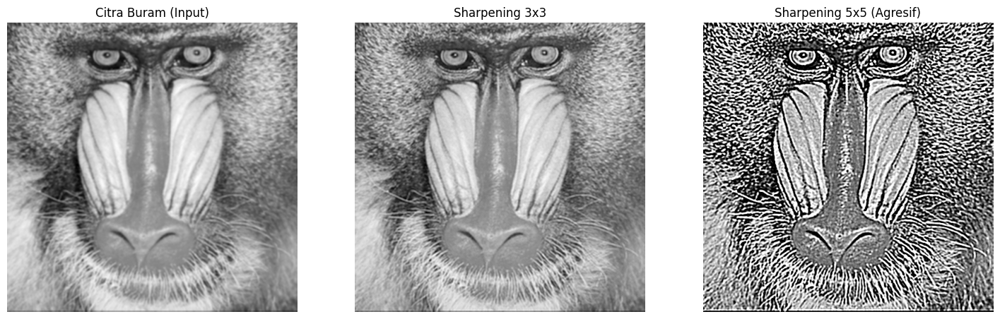

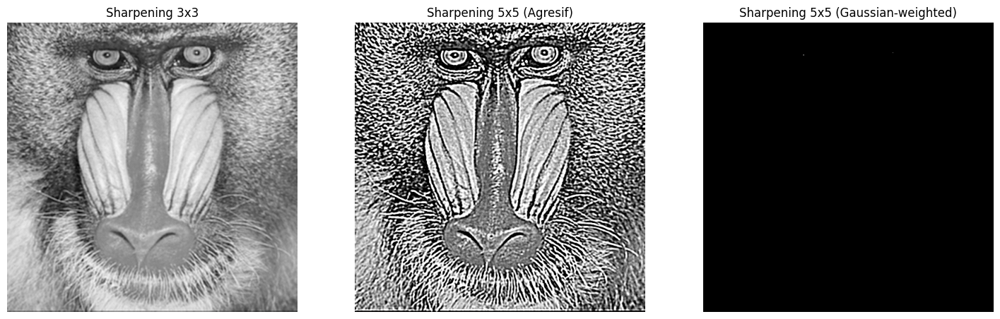

In [23]:
# Tugas 2: Pemilihan Ukuran Kernel Sharpening 3x3 vs 5x5

# 1. Menyiapkan citra input yang sedikit buram (blurry image)
blurry_input = cv.GaussianBlur(img_gray, (5, 5), 1.5)

# 2. Merancang Kernel Sharpening 3x3
# Prinsip: Piksel pusat diperkuat, tetangga langsung dikurangkan, total jumlah bobot = 1
kernel_sharp_3x3 = np.array([[ 0, -1,  0],
                             [-1,  5, -1],
                             [ 0, -1,  0]], dtype=np.float32)

# 3. Merancang Kernel Sharpening 5x5
# Prinsip: Memperluas radius tetangga (24 piksel sekeliling dikurangkan, pusat bernilai 25, total jumlah bobot = 1)
kernel_sharp_5x5 = np.array([[-1, -1, -1, -1, -1],
                             [-1, -1, -1, -1, -1],
                             [-1, -1, 25, -1, -1],
                             [-1, -1, -1, -1, -1],
                             [-1, -1, -1, -1, -1]], dtype=np.float32)

# Alternatif Kernel 5x5 berbasis Gaussian High-boost (Unsharp Masking 5x5) yang terkalibrasi halus:
# Disediakan pula perbandingan untuk melihat perbedaan karakteristik
kernel_sharp_5x5_smooth = np.array([[-1, -2, -3, -2, -1],
                                    [-2, -4, -6, -4, -2],
                                    [-3, -6, 57, -6, -3],
                                    [-2, -4, -6, -4, -2],
                                    [-1, -2, -3, -2, -1]], dtype=np.float32) / 9.0

# 4. Menerapkan konvolusi sharpening menggunakan filter2D
sharp_res_3x3 = cv.filter2D(blurry_input, -1, kernel_sharp_3x3)
sharp_res_5x5 = cv.filter2D(blurry_input, -1, kernel_sharp_5x5)
sharp_res_5x5_smooth = cv.filter2D(blurry_input, -1, kernel_sharp_5x5_smooth)

# 5. Visualisasi Hasil
show_side_by_side([blurry_input, sharp_res_3x3, sharp_res_5x5],
                  ["Citra Buram (Input)", "Sharpening 3x3", "Sharpening 5x5 (Agresif)"],
                  figsize=(18, 6))

show_side_by_side([sharp_res_3x3, sharp_res_5x5, sharp_res_5x5_smooth],
                  ["Sharpening 3x3", "Sharpening 5x5 (Agresif)", "Sharpening 5x5 (Gaussian-weighted)"],
                  figsize=(18, 6))

#### Evaluasi dan Analisis Tugas 2:

| Aspek Evaluasi | Kernel Sharpening 3 x 3 | Kernel Sharpening 5 x 5 |
| :--- | :--- | :--- |
| **Kejelasan Tepi (*Edge Crispness*)** | Meningkatkan ketajaman tepi dengan transisi alami (*natural sharpness*). Garis batas objek (kumis, mata, bulu) tampak tegas tanpa merusak struktur visual. | Garis tepi terlihat sangat tajam dan tebal secara berlebihan (*hyper-sharpened*). Muncul efek **halo / overshooting** (garis putih menyilaukan di sebelah garis kontras tinggi). |
| **Kadar Noise & Distorsi (*Noise Distortion*)** | Distorsi noise sangat minim. Fluktuasi intensitas mikroskopis pada area datar tetap terkendali dan tidak menonjol. | Mengamplifikasi noise lokal secara ekstrem (*severe noise amplification*). Area datar (seperti hidung/pipi mandrill) menjadi sangat kasar, berbintik-bintik tajam (*grainy*), dan kehilangan tekstur alami. |
| **Beban Komputasi** | Rendah ($3 \times 3 = 9$ perkalian/piksel), proses konvolusi sangat cepat. | Lebih tinggi ($5 \times 5 = 25$ perkalian/piksel), membutuhkan komputasi hampir 3 kali lipat. |

**Penentuan Kernel Paling Optimal:**
* **Kernel 3 x 3 adalah pilihan yang paling optimal dan seimbang untuk penggunaan sehari-hari.**
* *Alasan:* Kernel $3 \times 3$ memberikan pemulihan detail ketajaman yang cukup untuk mengatasi kekaburan (*blur*) tanpa menimbulkan efek samping distorsi cincin (*ringing artifacts*) maupun penguatan bintik noise yang merusak kualitas estetika foto.

---
### Tugas 3: Kreasi Filter Kartun Sederhana
1. Buatlah sebuah fungsi kustom bernama `kartun(image)` yang menggabungkan:
   * Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata (*flat color / cel-shaded look*).
   * Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
   * Penggabungan (kombinasi) keduanya menggunakan operasi logika / perkalian piksel.
2. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.

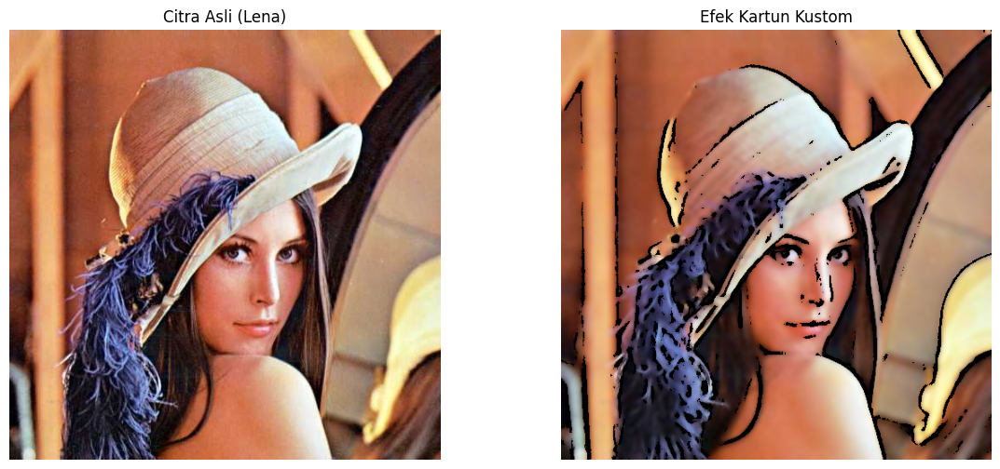

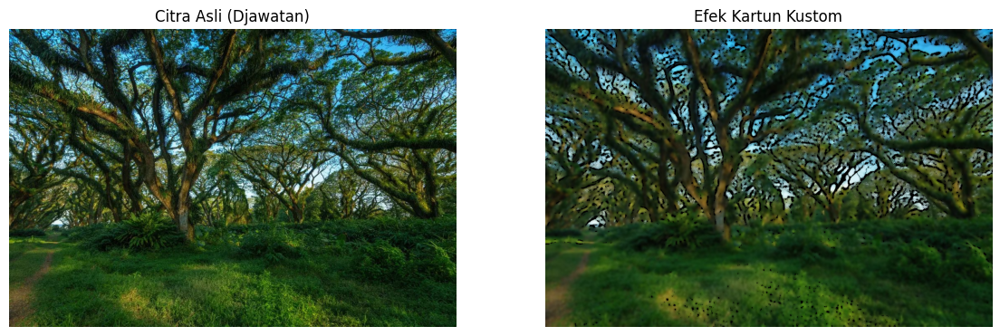

In [24]:
# Tugas 3: Pembuatan Fungsi Kustom kartun(image)

def kartun(image):
    """
    Fungsi kustom untuk mengubah citra RGB menjadi ilustrasi berefek kartun (cartoonized image).

    Langkah:
    1. Penghalusan warna bertingkat dengan Bilateral Filter agar warna menjadi homogen (cel-shaded).
    2. Ekstraksi garis tepi yang tebal dan bersih menggunakan Median Blur + Adaptive Thresholding.
    3. Penggabungan layer warna dan layer garis tepi menggunakan operasi logika bitwise AND.
    """
    # Pastikan citra memiliki 3 kanal (BGR)
    if len(image.shape) != 3:
        raise ValueError("Input citra harus merupakan citra berwarna (3 channel).")

    # --- Langkah 1: Ekstraksi Garis Tepi (Edge Contours) ---
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    # Median blur untuk membersihkan tekstur halus sebelum deteksi tepi agar garis kartun tidak kotor
    gray_blurred = cv.medianBlur(gray, 7)
    # Adaptive Thresholding menghasilkan garis tepi sketsa kartun hitam-putih
    edges = cv.adaptiveThreshold(gray_blurred, 255,
                                cv.ADAPTIVE_THRESH_MEAN_C,
                                cv.THRESH_BINARY,
                                blockSize=9,
                                C=9)

    # --- Langkah 2: Perataan Warna (Color Smoothing dengan Bilateral Filter) ---
    # Terapkan bilateral filter untuk menghaluskan warna kulit/latar namun menjaga tepian
    color_smooth = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # --- Langkah 3: Penggabungan Warna dan Garis Tepi ---
    # Operasi bitwise AND menempelkan garis kontur hitam (nilai 0 pada mask) ke atas citra warna
    cartoon_image = cv.bitwise_and(color_smooth, color_smooth, mask=edges)

    return cartoon_image

# Menguji fungsi kartun pada citra Lena dan Djawatan
kartun_lena = kartun(img_lena)
show_side_by_side([img_lena, kartun_lena], ["Citra Asli (Lena)", "Efek Kartun Kustom"], figsize=(14, 6))

kartun_djawatan = kartun(img_djawatan)
show_side_by_side([img_djawatan, kartun_djawatan], ["Citra Asli (Djawatan)", "Efek Kartun Kustom"], figsize=(14, 6))

### Penjelasan Alur Kerja Fungsi `kartun(image)`:
1. **Prapemrosesan Garis Sketsa:**
   * Citra masukan dikonversi ke grayscale.
   * `cv.medianBlur(gray, 7)` diaplikasikan untuk meredam detail mikro/noise tanpa merusak batas struktural objek.
   * `cv.adaptiveThreshold` menghitung ambang batas lokal secara adaptif pada tetangga $9 \times 9$. Hasilnya adalah citra biner di mana garis batas objek bernilai hitam (0) dan area datar bernilai putih (255).
2. **Penyederhanaan Palet Warna (*Flat Coloring*):**
   * `cv.bilateralFilter` memfilter variasi intensitas warna yang kecil, sehingga gradasi warna kulit dan latar belakang berubah menjadi bidang-bidang warna datar (*cel-shading* ala animasi komik).
3. **Komposisi Akhir:**
   * Masker garis biner dikombinasikan dengan citra warna menggunakan `cv.bitwise_and`. Pada piksel masker bernilai 0 (garis kontur kartun), hasil keluaran bernilai 0 (tinta hitam kartun), sedangkan pada masker bernilai 255 warna asli tetap dipertahankan.